In [20]:
import torch, yaml, warnings
import pandas as pd
from pathlib import Path
from torch.optim import AdamW
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.data import split_loaders
from src.ndp import NDP
from src.utils import build_scheduler
from src.radiomap.metrics import rmse, pcrr
warnings.filterwarnings("ignore")

In [2]:
cfg = yaml.safe_load(open("configs/base.yaml"))
cfg

{'csv': 'datasets/radiomap/train_2304601.csv',
 'batch': 1024,
 'train_rate': 0.5,
 'N': 1,
 'D': 2,
 'T': 25,
 'hidden': 256,
 'layers': 6,
 'lr': 0.0003,
 'lr_min': 1e-06,
 'epochs': 300,
 'ckpt': 'results/checkpoints/ndp_best.pt',
 'save': 'results/radiomap/train_2304601_ndp.png',
 'seed': 2025}

In [ ]:
def evaluate(model_wrap, loader, device):
    y_true_all, y_pred_all = [], []
    model_wrap.model.eval()
    with torch.no_grad():
        for x, y in tqdm(loader, desc="[Eval]", leave=False):
            x, y = x.to(device), y.to(device)
            y_hat = model_wrap.sample(x, seq_len=y.shape[1])
            y_true_all.append(y)
            y_pred_all.append(y_hat)
    y_true = torch.cat(y_true_all)
    y_pred = torch.cat(y_pred_all)
    return rmse(y_true, y_pred), pcrr(y_true, y_pred)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tr_dl, te_dl = split_loaders(
    cfg["csv"], cfg["batch"], split=cfg["train_rate"], seed=cfg["seed"]
)
cfg["iter_per_epoch"] = len(tr_dl)

save_dir = Path(cfg.get("save_dir", "results"))
ckpt_dir = save_dir / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)

ndp_wrap = NDP(
    cfg["D"], cfg["T"], hidden=cfg["hidden"], n_layers=cfg["layers"], device=device
)
model = ndp_wrap.model
opt = AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-2)
lr_sched = build_scheduler(opt, cfg)

train_losses, val_rmses, val_pcrrs = [], [], []
best_rmse = float("inf")
for epoch in range(cfg["epochs"]):
    avg_loss = ndp_wrap.train_epoch(tr_dl, epoch, opt, device, lr_sched)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        rmse_val, pcrr_val = evaluate(ndp_wrap, te_dl, device)
        val_rmses.append(rmse_val)
        val_pcrrs.append(pcrr_val)
        if rmse_val < best_rmse:
            best_rmse = rmse_val
            torch.save(model.state_dict(), ckpt_dir / "ndp_best.pt")

[Eval]:   0%|          | 0/4 [00:00<?, ?it/s]

[Train] Epoch 0 | Avg Loss=0.9806
[Val]   RMSE=1.038 | PCRR=0.220


[Eval]:   0%|          | 0/4 [00:00<?, ?it/s]

[Train] Epoch 9 | Avg Loss=0.3151
[Val]   RMSE=0.218 | PCRR=0.168


[Eval]:   0%|          | 0/4 [00:00<?, ?it/s]

...

[Train] Epoch 279 | Avg Loss=0.1483
[Val]   RMSE=0.109 | PCRR=0.552


[Eval]:   0%|          | 0/4 [00:00<?, ?it/s]

[Train] Epoch 289 | Avg Loss=0.1391
[Val]   RMSE=0.115 | PCRR=0.546


[Eval]:   0%|          | 0/4 [00:00<?, ?it/s]

[Train] Epoch 299 | Avg Loss=0.1440
[Val]   RMSE=0.112 | PCRR=0.525


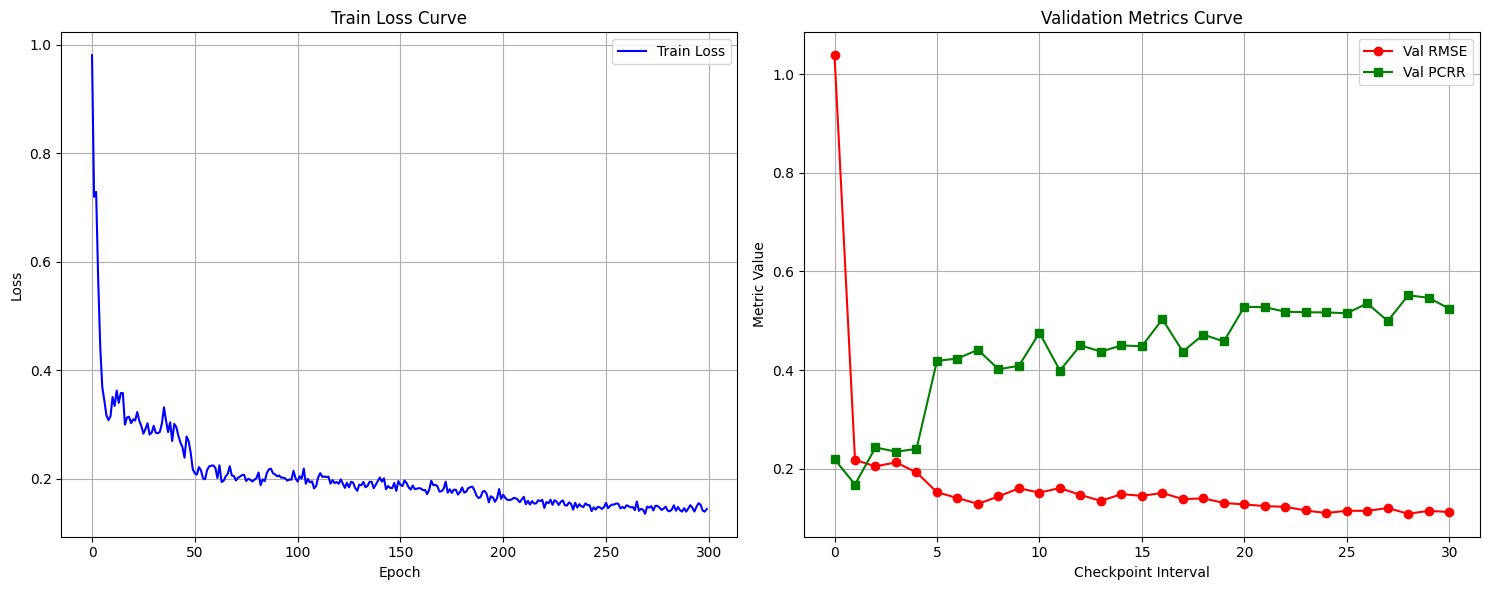

In [4]:
%matplotlib inline
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(range(len(train_losses)), train_losses, "b-", label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Train Loss Curve")
ax1.grid(True)
ax1.legend()

ax2.plot(range(len(val_rmses)), val_rmses, "r-", marker="o", label="Val RMSE")
ax2.plot(range(len(val_pcrrs)), val_pcrrs, "g-", marker="s", label="Val PCRR")
ax2.set_xlabel("Checkpoint Interval")
ax2.set_ylabel("Metric Value")
ax2.set_title("Validation Metrics Curve")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

  0%|          | 0/127 [00:00<?, ?it/s]

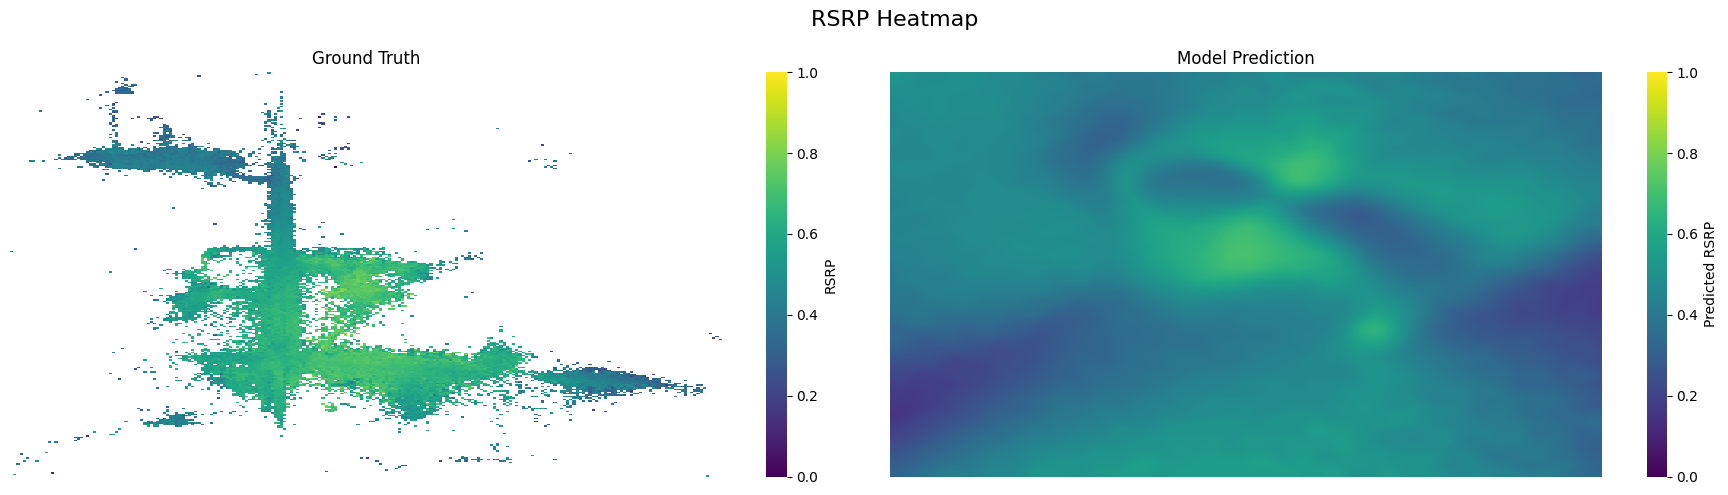

In [ ]:
import numpy as np
import seaborn as sns
from src.radiomap.visualize_rsrp import interpolate_grid, apply_smoothing, load_model


df = pd.read_csv(cfg["csv"])
batch_size = cfg.get("batch", 256)


pivot_true = df.pivot_table(index="Y", columns="X", values="RSRP")
model = load_model(cfg, device)
x_cols = [c for c in df.columns if c.upper() != "RSRP"]

grid_df = interpolate_grid(360)
predictions = []
x_tensor = torch.tensor(grid_df[x_cols].values.astype("float32"), device=device)
with torch.no_grad():
    for i in tqdm(range(0, len(grid_df), batch_size)):
        batch = x_tensor[i : i + batch_size].unsqueeze(1)
        batch_pred = model.sample(batch, 1).squeeze().cpu().numpy()
        predictions.append(batch_pred)
grid_df["RSRP_PRED"] = np.concatenate(predictions)
pivot_pred = grid_df.pivot_table(index="Y", columns="X", values="RSRP_PRED")

pivot_pred_values = pivot_pred.values
smoothed_values = apply_smoothing(pivot_pred_values)
pivot_pred = pd.DataFrame(
    smoothed_values, index=pivot_pred.index, columns=pivot_pred.columns
)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.heatmap(  # 绘制真实值热图（仅包含原始数据点）
    pivot_true.sort_index(ascending=False),
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    ax=axes[0],
    cbar_kws={"label": "RSRP"},
)
axes[0].set_title("Ground Truth")
axes[0].axis("off")
sns.heatmap(  # 绘制预测热图（可能是完整网格）
    pivot_pred.sort_index(ascending=False),
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    ax=axes[1],
    cbar_kws={"label": "Predicted RSRP"},
)
axes[1].set_title(f"Model Prediction")
axes[1].axis("off")
plt.suptitle("RSRP Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
def evaluate_with_noise(model, test_loader, device, noise_level=0.0):
    """在测试数据上评估模型在指定噪声水平下的性能"""
    y_true_all, y_pred_all = [], []
    model.model.eval()

    with torch.no_grad():
        for x, y in tqdm(
            test_loader, desc=f"[噪声水平={noise_level:.3f}]", leave=False
        ):
            x, y = x.to(device), y.to(device)

            if noise_level > 0:
                # 添加高斯噪声到特征
                noise = torch.randn_like(x) * noise_level
                x_noisy = x + noise
                # 确保噪声后的值仍在合理范围内 [0, 1]
                x_noisy = torch.clamp(x_noisy, 0, 1)
                y_hat = model.sample(x_noisy, 1)
            else:
                y_hat = model.sample(x, 1)

            y_true_all.append(y)
            y_pred_all.append(y_hat)

    y_true = torch.cat(y_true_all)
    y_pred = torch.cat(y_pred_all)

    return {
        "rmse": rmse(y_true, y_pred),
        "pcrr": pcrr(y_true, y_pred),
        "noise_level": noise_level,
    }

results = []
for noise_level in [0.0, 0.01, 0.02, 0.03, 0.04, 0.05]:
    result = evaluate_with_noise(model, te_dl, device, noise_level)
    results.append(result)
    print(f"[噪声={noise_level:.3f}] RMSE={result['rmse']:.5f} | PCRR={result['pcrr']:.5f}")

[噪声水平=0.000]:   0%|          | 0/4 [00:00<?, ?it/s]

[噪声=0.000] RMSE=0.10343 | PCRR=0.50045


[噪声水平=0.010]:   0%|          | 0/4 [00:00<?, ?it/s]

[噪声=0.010] RMSE=0.10822 | PCRR=0.49568


[噪声水平=0.020]:   0%|          | 0/4 [00:00<?, ?it/s]

...

[噪声=0.030] RMSE=0.11697 | PCRR=0.39897


[噪声水平=0.040]:   0%|          | 0/4 [00:00<?, ?it/s]

[噪声=0.040] RMSE=0.12546 | PCRR=0.40169


[噪声水平=0.050]:   0%|          | 0/4 [00:00<?, ?it/s]

[噪声=0.050] RMSE=0.13905 | PCRR=0.36595


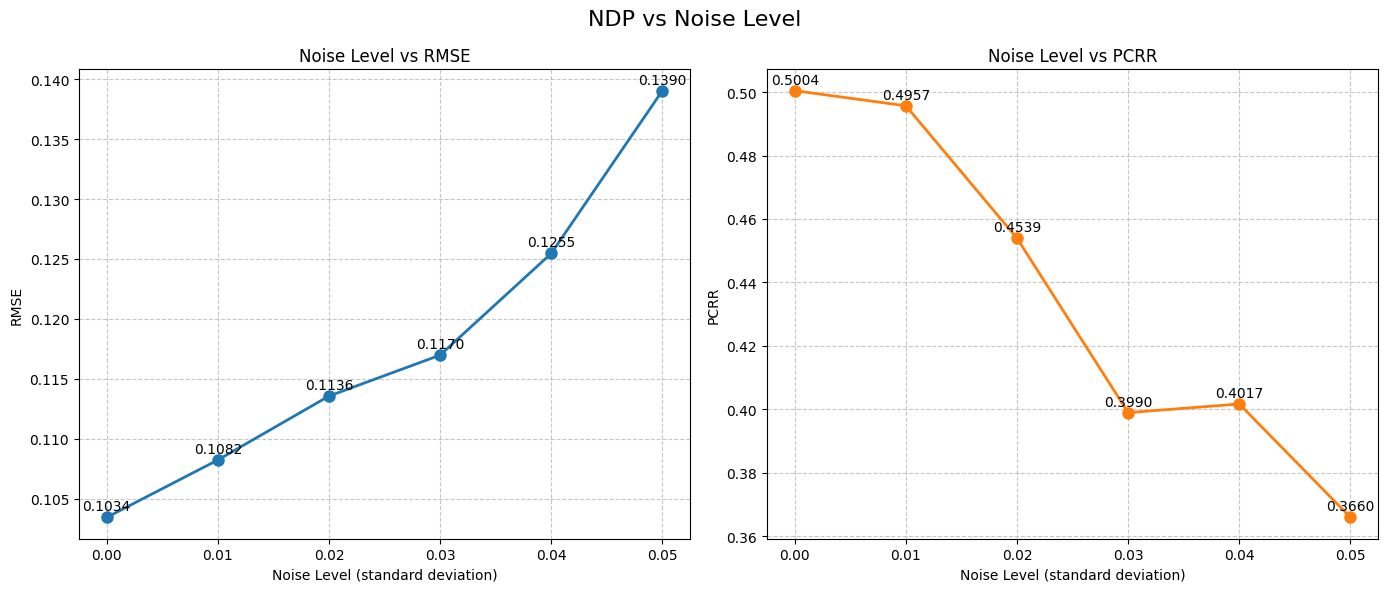

In [8]:
noise_levels = [r["noise_level"] for r in results]
rmse_values = [r["rmse"] for r in results]
pcrr_values = [r["pcrr"] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(
    noise_levels, rmse_values, "o-", color="#1f77b4", linewidth=2, markersize=8
)
ax1.set_xlabel("Noise Level (standard deviation)")
ax1.set_ylabel("RMSE")
ax1.set_title("Noise Level vs RMSE")
ax1.grid(True, linestyle="--", alpha=0.7)

for i, (x, y) in enumerate(zip(noise_levels, rmse_values)):
    ax1.annotate(
        f"{y:.4f}", (x, y), xytext=(0, 5), textcoords="offset points", ha="center"
    )

ax2.plot(
    noise_levels, pcrr_values, "o-", color="#ff7f0e", linewidth=2, markersize=8
)
ax2.set_xlabel("Noise Level (standard deviation)")
ax2.set_ylabel("PCRR")
ax2.set_title("Noise Level vs PCRR")
ax2.grid(True, linestyle="--", alpha=0.7)

for i, (x, y) in enumerate(zip(noise_levels, pcrr_values)):
    ax2.annotate(
        f"{y:.4f}", (x, y), xytext=(0, 5), textcoords="offset points", ha="center"
    )

plt.suptitle("NDP vs Noise Level", fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
cfg = yaml.safe_load(open("configs/transfer.yaml"))


In [13]:
from torch.utils.data import DataLoader, ConcatDataset
from src.data import RSMap


def load_data(train_csv_paths, test_csv_path, batch_size):
    train_ds = ConcatDataset([RSMap(Path(csv_path)) for csv_path in train_csv_paths])
    print(f"合并后训练集样本总数: {len(train_ds)}")
    test_ds = RSMap(Path(test_csv_path))
    print(f"加载测试集: {test_csv_path}, 样本数: {len(test_ds)}")
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=True)
    return train_dl, test_dl

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tr_dl, te_dl = load_data(cfg["train_csv_paths"], cfg["test_csv_path"], cfg["batch"])
cfg["iter_per_epoch"] = len(tr_dl)
ndp_wrap = NDP(
    cfg["D"], cfg["T"], device, hidden=cfg["hidden"], n_layers=cfg["layers"]
)
model = ndp_wrap.model

model.load_state_dict(torch.load(cfg["load_ckpt"], map_location=device))

合并后训练集样本总数: 14236
加载测试集: datasets/radiomap/train_2304601.csv, 样本数: 9369


<All keys matched successfully>

  0%|          | 0/64 [00:00<?, ?it/s]

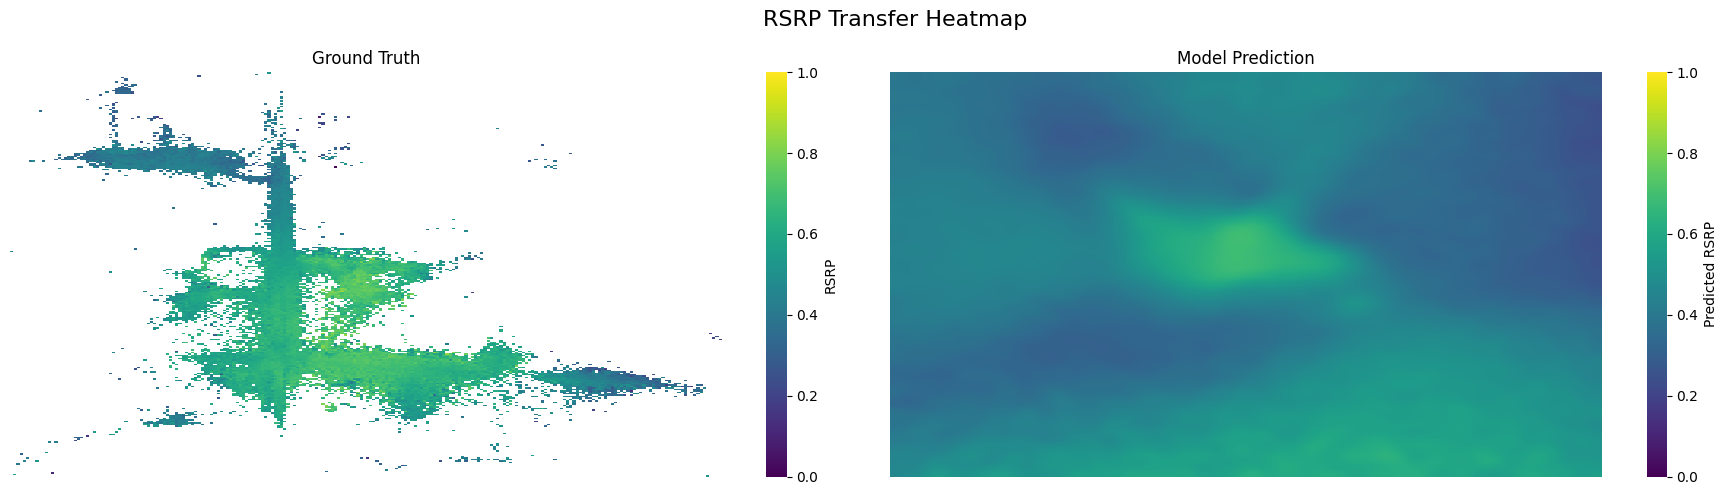

In [22]:
from src.radiomap.visualize_rsrp import interpolate_grid, apply_smoothing


df = pd.read_csv(cfg["csv"])
batch_size = 2048
pivot_true = df.pivot_table(index="Y", columns="X", values="RSRP")
x_cols = [c for c in df.columns if c.upper() != "RSRP"]

grid_df = interpolate_grid(360)
predictions = []
x_tensor = torch.tensor(grid_df[x_cols].values.astype("float32"), device=device)
with torch.no_grad():
    for i in tqdm(range(0, len(grid_df), batch_size)):
        batch = x_tensor[i : i + batch_size].unsqueeze(1)
        batch_pred = ndp_wrap.sample(batch, 1).squeeze().cpu().numpy()
        predictions.append(batch_pred)
grid_df["RSRP_PRED"] = np.concatenate(predictions)
pivot_pred = grid_df.pivot_table(index="Y", columns="X", values="RSRP_PRED")

pivot_pred_values = pivot_pred.values
smoothed_values = apply_smoothing(pivot_pred_values)
pivot_pred = pd.DataFrame(
    smoothed_values, index=pivot_pred.index, columns=pivot_pred.columns
)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.heatmap(
    pivot_true.sort_index(ascending=False),
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    ax=axes[0],
    cbar_kws={"label": "RSRP"},
)
axes[0].set_title("Ground Truth")
axes[0].axis("off")
sns.heatmap(
    pivot_pred.sort_index(ascending=False),
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    ax=axes[1],
    cbar_kws={"label": "Predicted RSRP"},
)
axes[1].set_title(f"Model Prediction")
axes[1].axis("off")
plt.suptitle("RSRP Transfer Heatmap", fontsize=16)
plt.tight_layout()
plt.show()